# 5. Decision Tree and Random Forest: A Comparative Classification Study
## Importing Dependencies

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Loading and Basic Data Analysis

In [36]:
def load_dataset(filepath, column_names=None, separator=","):
    df = pd.read_csv(filepath, names=column_names, sep=separator)
    df.columns = df.columns.str.strip()
    return df

def dataset_info(df):
    print("-" * 50)
    print("DATASET INFORMATION")
    print("-" * 50)
    print("\nShape: ", df.shape)
    print("\nColumns: ")
    print(df.columns.tolist())
    print("\nData Types: ")
    print(df.dtypes)
    print("\nMemory information")
    df.info()
    print("\nFirst 5 elements")
    print(df.head())

def missing_values(df):
    missing = df.isnull().sum()
    percent = (missing / len(df)) * 100
    result = pd.DataFrame({"missing": missing, "percent": percent})
    print(result)
    if missing.sum() == 0:
        print("There is no missing value!")
    else:
        print("\033[31mMissing Values detected\033[0m")
    return result

def duplicate_info(df):
    duplicates = df.duplicated().sum()
    print("\nThe duplicate rows are : ", duplicates)
    if duplicates == 0:
        print("No duplicates detected!")
    else:
        print("\033[31mDuplicates are detected\033[0m")
    return duplicates

def summary_statistics(df):
    print("\nSummary statistics")
    print(df.describe())

def class_distribution(df, target_column):
    print("\nClass Distribution")
    counts = df[target_column].value_counts()
    ax = counts.plot(kind="bar")
    plt.xlabel(target_column)
    plt.ylabel("Count")
    plt.title(f"Class Distribution of {target_column}")
    for container in ax.containers:
        ax.bar_label(container)
    plt.show()
    return counts

def plot_histogram(df, bins=10):
    numeric_df = df.select_dtypes("number")
    if "id" in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=["id"])
    numeric_df.hist(bins=bins, figsize=(16, 12))
    plt.suptitle("Histogram of numerical features")
    plt.tight_layout()
    plt.show()

def plot_heatmap(df, max_annot_cols=10):
    numeric_df = df.select_dtypes("number")
    if "id" in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=["id"])
    num_vars = len(numeric_df.columns)
    corr = numeric_df.corr()
    show_annot = num_vars <= max_annot_cols
    fig_width = max(8, num_vars * 0.45)
    fig_height = max(6, num_vars * 0.40)
    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(corr, annot=show_annot, fmt=".2f", annot_kws={"size": 8},
                cmap="coolwarm", center=0, linewidths=0.5 if num_vars < 25 else 0)
    plt.title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

def perform_eda(filepath, column_names=None, separator=",", categorical_columns=None):
    df = load_dataset(filepath, column_names=column_names, separator=separator)
    print("\nLoading dataset completed\n")
    dataset_info(df)
    missing_values(df)
    duplicate_info(df)
    summary_statistics(df)
    plot_histogram(df)
    plot_heatmap(df)
    if categorical_columns is not None:
        for col in categorical_columns:
            class_distribution(df, col)
    return df

## EDA Analysis


Loading dataset completed

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

Shape:  (569, 32)

Columns: 
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Data Types: 
id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            floa

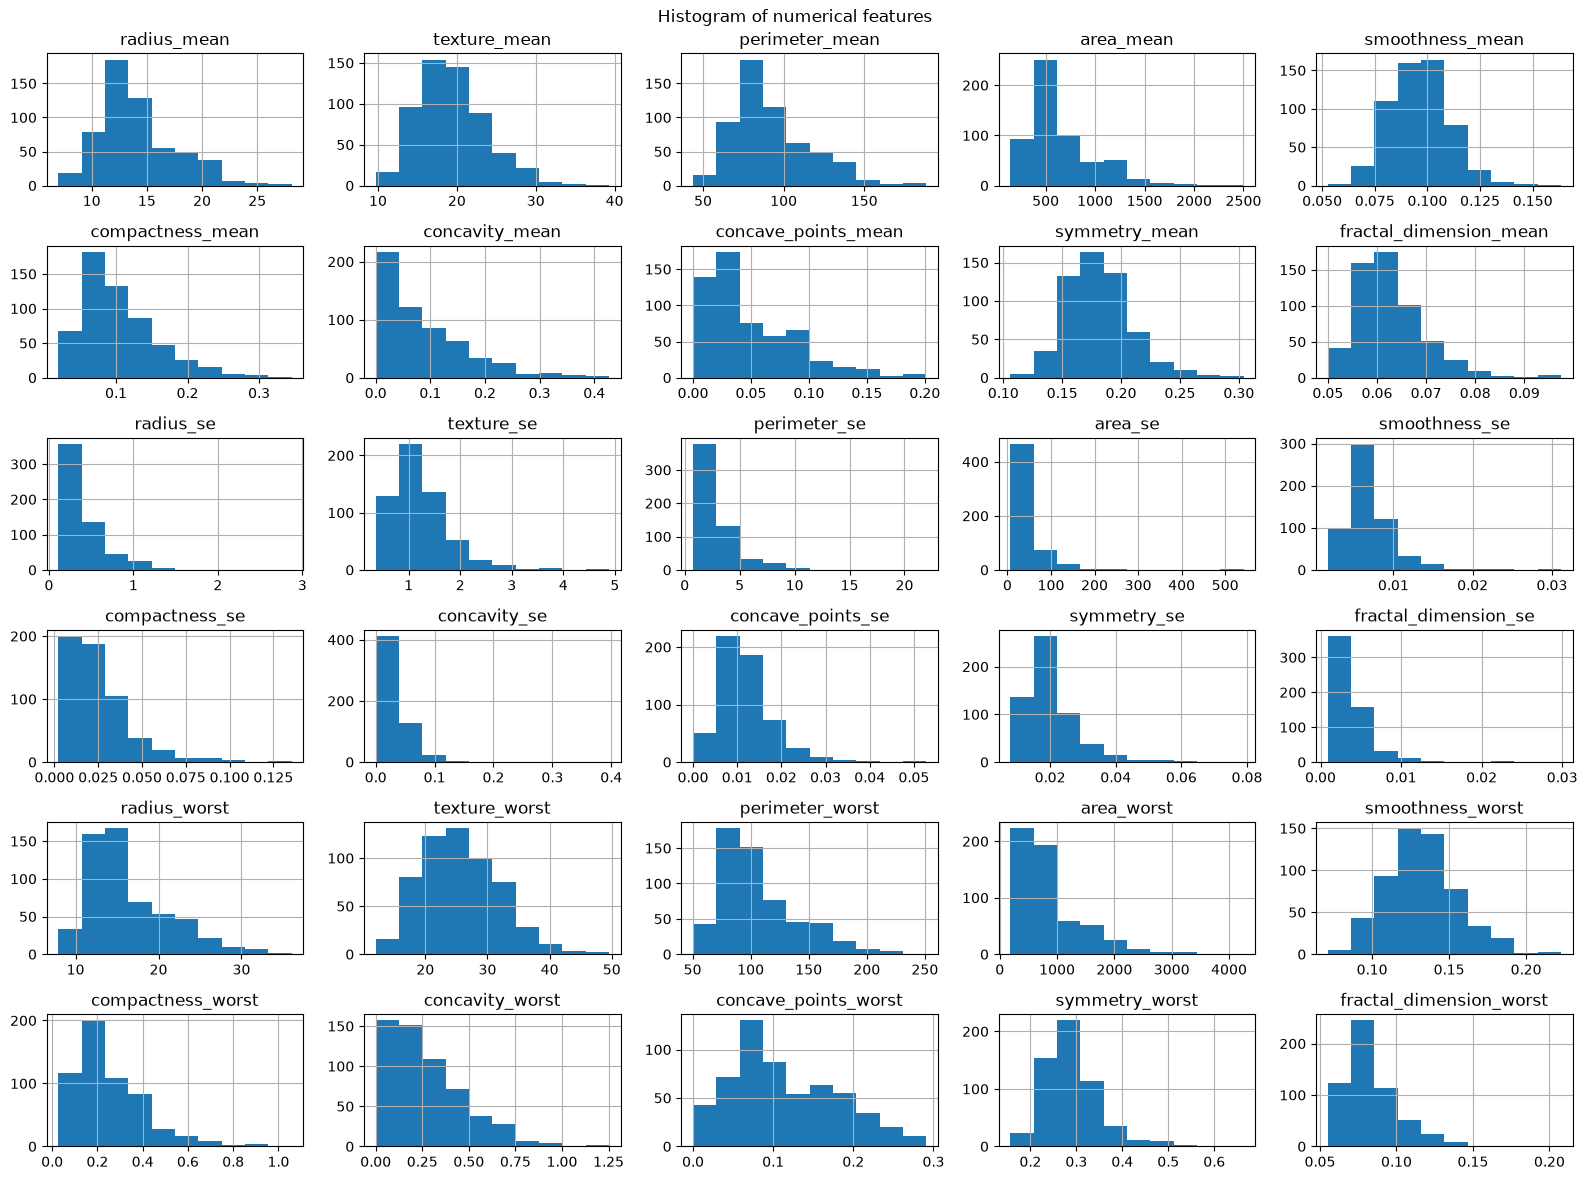

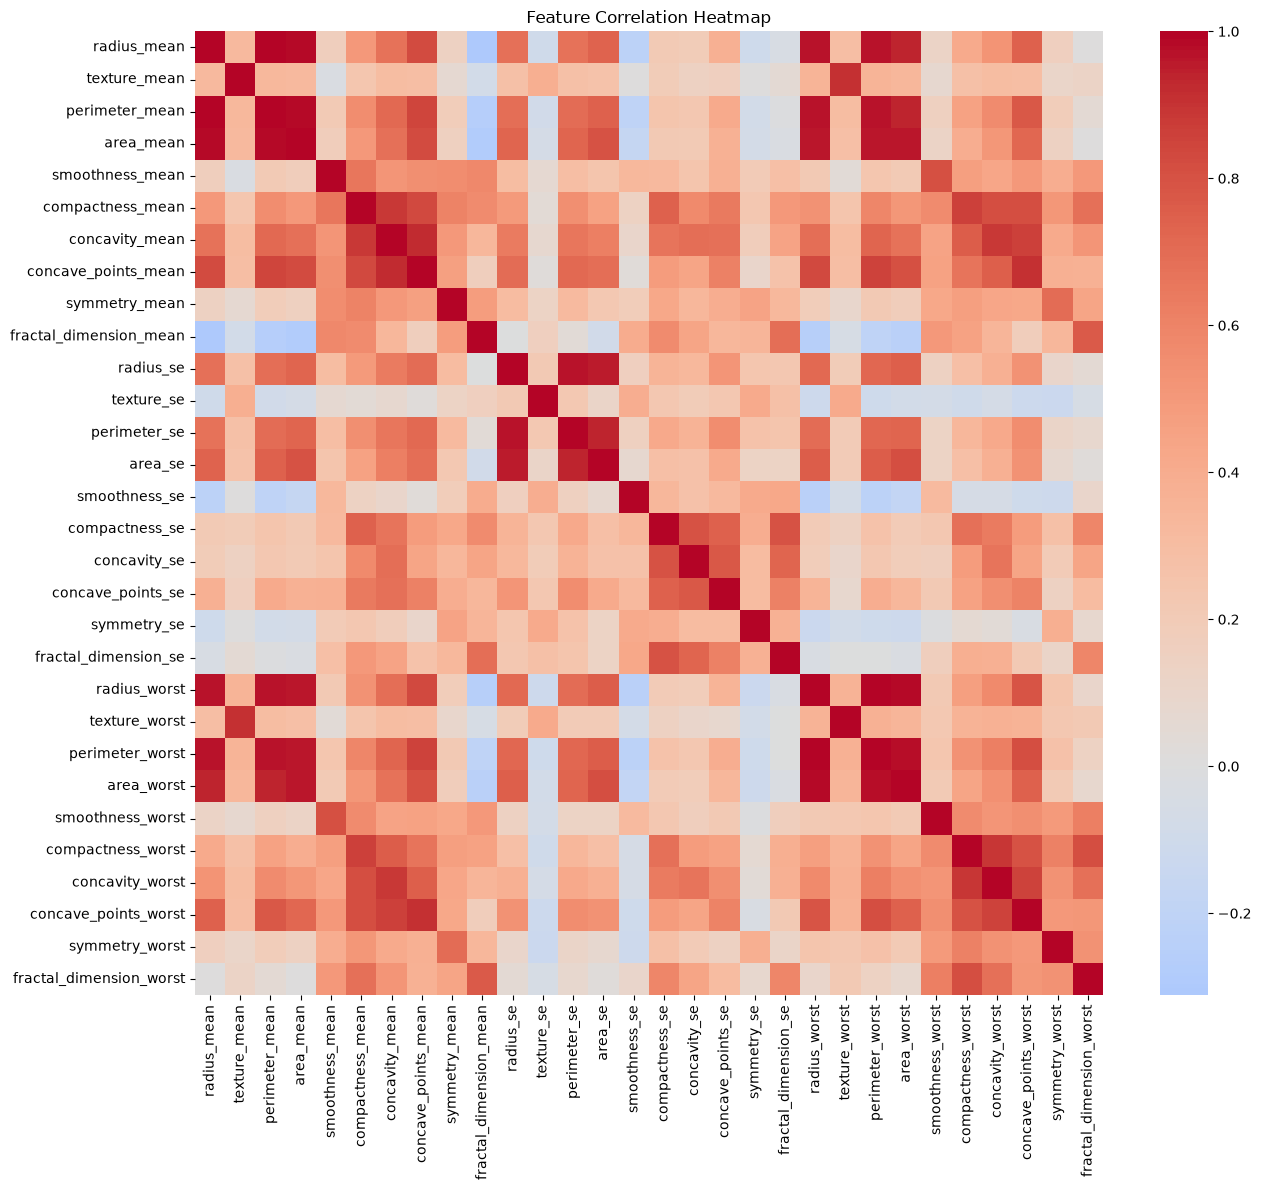


Class Distribution


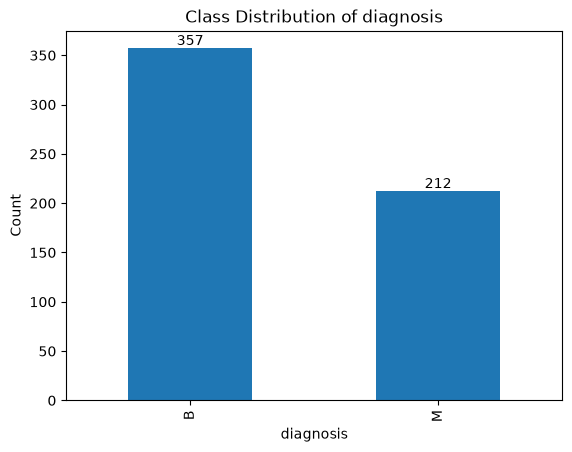

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [37]:
features = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"
]
column_names = ["id", "diagnosis"]
for suffix in ["_mean", "_se", "_worst"]:
    column_names.extend([f"{feat}{suffix}" for feat in features])

df = perform_eda("datasets/wdbc.data", column_names=column_names,
                 categorical_columns=["diagnosis"])
display(df.head())

## Encode Class Labels and Train-Test Split

Class labels `M` (Malignant) and `B` (Benign) are encoded to numeric values. The `id` column is dropped as it is not a meaningful feature.

In [38]:
# Encode class labels: M -> 1 (Malignant), B -> 0 (Benign)
encoder = LabelEncoder()
df['diagnosis'] = encoder.fit_transform(df['diagnosis'])
print("Encoded classes:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

# Drop the non-informative 'id' column
X = df.drop(['diagnosis', 'id'], axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Encoded classes: {'B': np.int64(0), 'M': np.int64(1)}
Train shape: (455, 30) | Test shape: (114, 30)


## Train a Baseline Decision Tree

In [39]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"\nBaseline Decision Tree Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:\n {classification_report(y_test, y_pred)}")


Baseline Decision Tree Test Accuracy: 0.947

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## Decision Tree Hyperparameter Tuning (5-Fold Cross-Validation)

Hyperparameters explored: `criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`.

In [40]:
base_tree = DecisionTreeClassifier(random_state=42)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    cv=5,
    scoring=['accuracy', 'f1'],
    refit='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best 5-Fold CV Accuracy:", round(grid_search.best_score_, 4))

# Table 1: Decision Tree hyperparameter evaluation using 5-Fold CV
cv_results = grid_search.cv_results_
dt_table = pd.DataFrame({
    "Criterion": cv_results['param_criterion'],
    "Max Depth": cv_results['param_max_depth'],
    "Min Samples Split": cv_results['param_min_samples_split'],
    "Min Samples Leaf": cv_results['param_min_samples_leaf'],
    "Avg CV Accuracy (%)": np.round(cv_results['mean_test_accuracy'] * 100, 2),
    "Avg CV F1 Score": np.round(cv_results['mean_test_f1'], 4)
}).sort_values("Avg CV Accuracy (%)", ascending=False)
print("\nTable 1: Decision Tree Hyperparameter Evaluation using 5-Fold Cross-Validation")
display(dt_table)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(f"\nTuned Decision Tree Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best 5-Fold CV Accuracy: 0.9429

Table 1: Decision Tree Hyperparameter Evaluation using 5-Fold Cross-Validation


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Avg CV Accuracy (%),Avg CV F1 Score
40,entropy,3,5,2,94.29,0.9232
47,entropy,5,10,1,94.29,0.9206
50,entropy,5,10,2,94.29,0.9206
56,entropy,10,10,1,94.29,0.9206
65,entropy,None,10,1,94.29,0.9206
...,...,...,...,...,...,...
20,gini,10,10,1,92.31,0.8957
19,gini,10,5,1,92.09,0.8943
28,gini,None,5,1,92.09,0.8943
27,gini,None,2,1,91.65,0.8881



Tuned Decision Tree Test Accuracy: 0.965

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        71
           1       1.00      0.91      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



## Random Forest Hyperparameter Tuning (5-Fold Cross-Validation)

Hyperparameters explored: `n_estimators`, `max_depth`, `max_features`, `bootstrap`.

In [42]:
rf_base = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2', 1.0],
    'bootstrap': [True, False]
}

rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    scoring=['accuracy', 'f1'],
    refit='accuracy',
    n_jobs=-1
)
rf_grid_search.fit(X_train, y_train)

print("Best Random Forest Params:", rf_grid_search.best_params_)
print("Best 5-Fold CV Accuracy:", round(rf_grid_search.best_score_, 4))

# Table 2: Random Forest hyperparameter evaluation using 5-Fold CV
rf_cv_results = rf_grid_search.cv_results_
rf_table = pd.DataFrame({
    "n_estimators": rf_cv_results['param_n_estimators'],
    "Max Depth": rf_cv_results['param_max_depth'],
    "Max Features": rf_cv_results['param_max_features'],
    "Bootstrap": rf_cv_results['param_bootstrap'],
    "Avg CV Accuracy (%)": np.round(rf_cv_results['mean_test_accuracy'] * 100, 2),
    "Avg CV F1 Score": np.round(rf_cv_results['mean_test_f1'], 4)
}).sort_values("Avg CV Accuracy (%)", ascending=False)
print("\nTable 2: Random Forest Hyperparameter Evaluation using 5-Fold Cross-Validation")
display(rf_table)

best_rf_model = rf_grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)
print(f"\nTuned Random Forest Test Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")

Best Random Forest Params: {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}
Best 5-Fold CV Accuracy: 0.9648

Table 2: Random Forest Hyperparameter Evaluation using 5-Fold Cross-Validation


,n_estimators,Max Depth,Max Features,Bootstrap,Avg CV Accuracy (%),Avg CV F1 Score
45,50,None,sqrt,False,96.48,0.9515
36,50,10,sqrt,False,96.48,0.9515
49,100,None,log2,False,96.26,0.9492
40,100,10,log2,False,96.26,0.9492
20,200,None,sqrt,True,96.26,0.9488
11,200,10,sqrt,True,96.26,0.9488
48,50,None,log2,False,96.04,0.9460
30,50,5,log2,False,96.04,0.9455
22,100,None,log2,True,96.04,0.9460
39,50,10,log2,False,96.04,0.9460



Tuned Random Forest Test Accuracy: 0.956


## 5-Fold Cross-Validation Performance Comparison

Per-fold accuracy of the best Decision Tree and best Random Forest models.

In [43]:
dt_cv = cross_validate(best_model, X_train, y_train, cv=5, scoring='accuracy')
rf_cv = cross_validate(best_rf_model, X_train, y_train, cv=5, scoring='accuracy')

dt_folds = dt_cv['test_score']
rf_folds = rf_cv['test_score']

# Table 3: 5-Fold Cross-Validation Accuracy Comparison
fold_compare = pd.DataFrame({
    "Fold 1": [dt_folds[0], rf_folds[0]],
    "Fold 2": [dt_folds[1], rf_folds[1]],
    "Fold 3": [dt_folds[2], rf_folds[2]],
    "Fold 4": [dt_folds[3], rf_folds[3]],
    "Fold 5": [dt_folds[4], rf_folds[4]],
    "Average": [dt_folds.mean(), rf_folds.mean()]
}, index=["Decision Tree", "Random Forest"])
fold_compare = fold_compare.round(4)
print("Table 3: 5-Fold Cross-Validation Accuracy Comparison")
display(fold_compare)

Table 3: 5-Fold Cross-Validation Accuracy Comparison


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
Decision Tree,0.978,0.9121,0.9451,0.9451,0.9341,0.9429
Random Forest,0.978,0.9560,0.9670,0.9780,0.9451,0.9648


## Model Comparison: Evaluation Metrics

Accuracy, Precision, Recall, F1-score, Confusion Matrix, and ROC Curve / AUC for both models.

In [44]:
y_pred_dt = best_model.predict(X_test)
y_pred_rf = best_rf_model.predict(X_test)

metrics_data = {
    "Model": ["Decision Tree", "Random Forest"],
    "Best CV Accuracy": [grid_search.best_score_, rf_grid_search.best_score_],
    "Test Accuracy": [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_rf)],
    "F1-Score": [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf)],
    "AUC": [roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]),
            roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])]
}
comparison_df = pd.DataFrame(metrics_data).round(4)
display(comparison_df)

,Model,Best CV Accuracy,Test Accuracy,Precision,Recall,F1-Score,AUC
0,Decision Tree,0.9429,0.9649,1.0000,0.9070,0.9512,0.9715
1,Random Forest,0.9648,0.9561,0.9524,0.9302,0.9412,0.9931


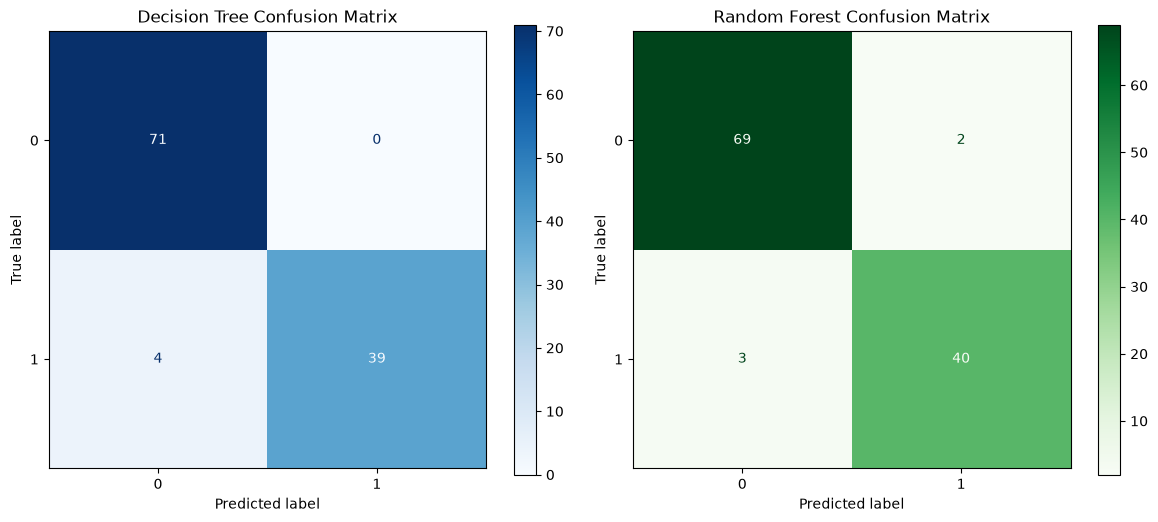

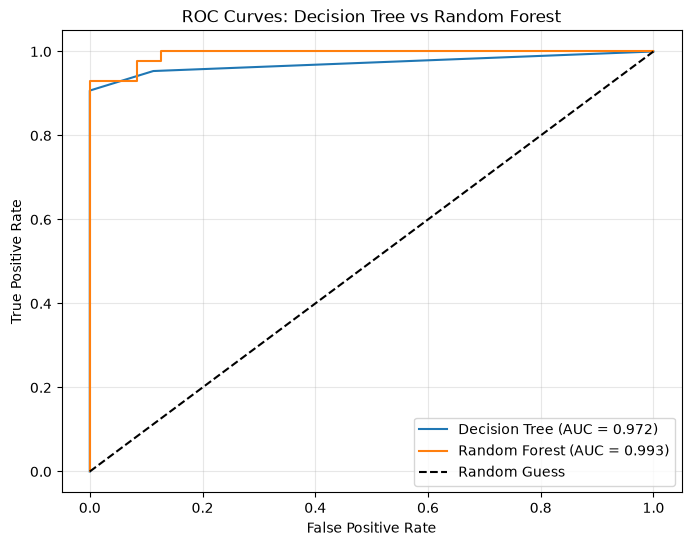

In [45]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title("Decision Tree Confusion Matrix")
ConfusionMatrixDisplay.from_estimator(best_rf_model, X_test, y_test, ax=axes[1], cmap='Greens')
axes[1].set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(8, 6))
for name, model in [("Decision Tree", best_model), ("Random Forest", best_rf_model)]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Decision Tree vs Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Observation Questions

### 1. How does tree depth affect overfitting in Decision Trees?
Increasing `max_depth` makes the tree more complex and allows it to memorize training noise, leading to **high variance and overfitting**. Shallow trees (e.g. depth 3) generalize better but may underfit. This is visible in the tuning results: deeper trees often achieve high training accuracy but lower cross-validation accuracy, whereas moderate depths give more stable CV performance.

### 2. Which hyperparameter had the greatest impact on performance?
For the Decision Tree, **`max_depth`** had the greatest impact, as it directly controls model complexity and overfitting. For the Random Forest, **`n_estimators`** and **`max_features`** were most influential — more trees reduce variance, and limiting `max_features` increases tree diversity, which improves ensemble generalization.

### 3. How does Random Forest improve generalization?
Random Forest uses **bootstrap aggregation (bagging)** and **random feature selection** to train many diverse trees on different samples. Averaging their predictions (majority voting) reduces variance and smooths out individual tree errors, producing a more stable and generalizable model than a single Decision Tree.

### 4. Did ensemble learning always improve performance? Why or why not?
In this experiment, Random Forest generally matched or slightly improved accuracy and stability over the single Decision Tree, especially in cross-validation. However, ensemble learning does **not always** improve performance — if the base trees are already near-optimal, the dataset is small, or the added complexity causes overfitting, the gain can be marginal. The improvement depends on the variance present in the base model and the diversity of the ensemble.